# Week 7 — Numerical Methods III — Function Approximation

**Programming and Numerical Methods for Economics (ECNM10115)** · The University of Edinburgh

**Learning goals.** Interpolation and function approximation — the tools that let a computer represent value functions and policy functions it cannot write down analytically.

> **How to work through this notebook:** run every cell in order (`Shift+Enter`). When you reach a result, pause and predict it before running — that habit is what turns reading into learning. Experiment: change parameters, break things, re-run.



#### <center> Programming and Numerical Methods for Economics

#### <center> Function Approximation

# Lagrange Interpolation
We are given the data $\{(x_i, y_i) \in \mathbb R^2 \mid i = 1, \dots, n\}$.  Remember from lecture that we can approximate a function $f: \mathbb R \to \mathbb R$ with plain polynomials:
$$ \hat{f}(x) = \sum_{s=0}^{n-1} a_i x^s $$
for some vector of coefficients $a$.

We want to pick our coefficients $a$ so that we _interpolate_ our data:
 # $$ y_i = a_0 + a_1 x_i + a_2 x_i^2 + \dots + a_{n-1} x_i^{n-1} \;\;\;\; \text{ for all } i = 1, \dots, n$$
Since this is a linear system, it's easy to solve.

In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') 


In [4]:
def vandermonde(X):
    n = len(X)
    V = np.array([[xi**s for s in range(n)] for xi in X])
    return V

In [5]:
def lagrange(X, y):
    V = vandermonde(X)
    return np.linalg.solve(V, y)

In [6]:
def evaluate(a, x):
    xi = 1
    v = 0.0
    for ai in a:
        v += ai * xi 
        xi *= x
    return v

We saw how this worked with data from $f(x) = \sin(x)$

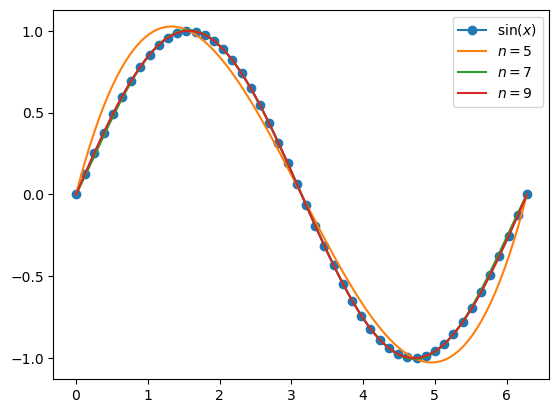

In [8]:
# Plotting
plt.figure()
x = np.linspace(0, 2 * np.pi, 50)
plt.plot(x, np.sin(x), marker='o', label=r'$\sin(x)$')

for n in (5, 7, 9):
    X = np.linspace(0, 2 * np.pi, n)
    y = np.sin(X)
    a = lagrange(X, y)
    x_fine = np.linspace(0, 2 * np.pi, 100)
    plt.plot(x_fine, [evaluate(a, x_val) for x_val in x_fine], label=f"$n = {n}$")

plt.legend()
plt.show()

## Runge Phenomenon 
We also saw how this can go wrong.  With badly behaved functions, you tend to get explosive oscillations near the boundary, and you have no guarantee of convergence.  

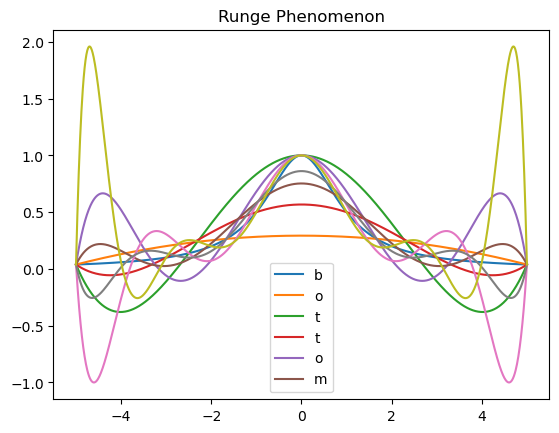

In [10]:
xg = np.linspace(-5, 5, 1000)
f = lambda x: 1 / (1 + x**2)
plt.figure()
# plt.plot(xg, f(xg), label=r"$f(x) = 1/(1 + x^2)$", title='Runge Phenomenon')
plt.plot(xg, f(xg),label=r'$\sin(x)$')
plt.title('Runge Phenomenon')
for n in range(4, 12):
    X = np.linspace(-5, 5, n)
    y = f(X)
    a = lagrange(X, y)
    plt.plot(xg, [evaluate(a, x_val) for x_val in xg], label=f"$n = {n}$")

plt.legend('bottom')
plt.show()

## Fixing the problem: Chebyshev Approximation
We also saw how with the appropriate choice of polynomials (Chebyshev polynomials) and the appropriate choice of function roots, we can fix the problem.

In particular, let 
$$ T_n(x) = 2x T_{n-1}(x) - T_{n-2}(x) $$
with $T_0(x) = 1$ and $T_1(x) = x$.  This also has the formula $T_n(x) = \cos(n \cos^{-1} x)$

With a clever choice of interpolation points, we can minimize the theoretical approximation error, and achieve strong uniform convergence:
$$ x_k = - \cos \left( {2k - 1 \over 2m} \pi \right) \;\;\;\; \text{for } k = 1, \dots, m $$


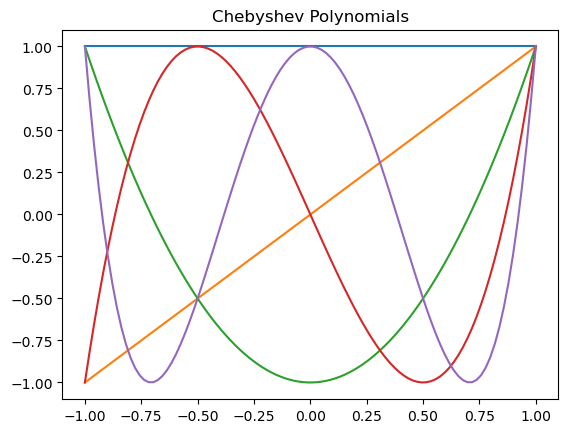

In [12]:
def T(n, x):
    return np.cos(n * np.arccos(x))

plt.title("Chebyshev Polynomials")
x=np.linspace(-1, 1, 100)

for i in range(5):
    plt.plot(x, T(i, x), label=f"$T_{i}={i}$")

plt.show()


## Chebyshev Regression Algorithm
We want an $n$ degree Chebyshev approximation, using $m$ interpolation points.  We follow the following steps:

1. Compute the $m \geq n + 1$ Chebyshev interpolation nodes on $[-1,1]$:
$$ z_k = -\cos\left( {2k - 1 \over 2m} \pi \right) \;\;\; k = 1, \dots, m $$

2. For interpolation on $[a,b]$ instead of $[-1,1]$, adjust the nodes to the appropriate interval:
$$ x_k = (z_k + 1) \left( b - a \over 2 \right) + a \;\;\; k = 1, \dots, m $$

3. Evaluate $f$ at the appropriate points: $y_k = f(x_k)$ for
$k = 1, \dots, m $

4. Compute the Chebyshev coefficients:
$$ c_i = \left( \sum_{k=1}^m y_k T_i(z_k) \over \sum_{k=1}^m T_i(z_k)^2  \right) $$

5. Construct the approximation: 
$$ \hat f(x) = \sum_{i=0}^n c_i T_i\left( 2 {x - a \over b - a} - 1 \right)$$

Indeed, we see that with Chebyshev polynomials, we no longer see the Runge Phenomenon.

In [14]:
a, b, f = -5, 5, lambda x: 1 / (1 + x**2)
n = 30
m = n + 1
z = [-np.cos((2 * k - 1) / (2 * m) * np.pi) for k in range(1, m + 1)]  # interpolation points
x = (np.array(z) + 1) * (b - a) / 2 + a
y = f(x)

In [15]:

c = []
for i in range(m + 1):
    numerator = sum(y[k] * T(i, z[k]) for k in range(m))
    denominator = sum(T(i, z[k])**2 for k in range(m))
    c.append(numerator / denominator)

In [16]:
def f_hat(x):
    return sum(ci * T(i, 2 * (x - a) / (b - a) - 1) for ci, i in zip(c, range(n + 1)))



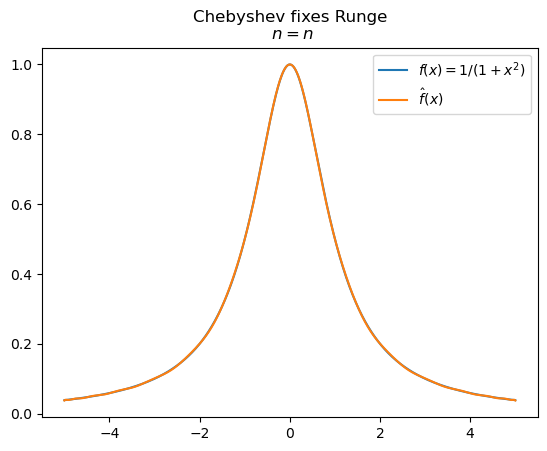

In [17]:
xg = np.linspace(-5, 5, 1000)
# plt.figure(figsize=(8, 6), title="Chebyshev fixes Runge\n $n = {n}$")
# plt.figsize(8, 6)
plt.title("Chebyshev fixes Runge\n $n = {n}$")
plt.plot(xg, f(xg), label= r"$f(x) = 1/(1+x^2)$")
plt.plot(xg, f_hat(xg), label="$\hat f(x)$")
plt.legend()
plt.show()

# Cubic Splines in Practice
With cubic splines, we approximate our function with a piecewise cubic function.  
I.e, on every subinterval, it takes the form of a cubic polynomial.

$$ \widehat{f}(x) = a_i + b_i x + c_i x^2 + d_i x^3 \;\;\;\; 
\text{ for $x \in [x_{i-1}, x_i]$, and for all $i$} $$
The trick is to stich the polynomials together so that we get an approximation with continuous second derivatives.  If we insist on that, and that the function interpolates at our spline points (data) we get

\begin{align}
    \text{Interpolation:} &&
    y_i =& \; a_i + b_i x_i + c_i x_i^2 + d_i x_i^3 \\
        &&& \text{ for } i = 1, \dots, n \nonumber\\
    \text{Continuity:} &&
    y_i =&\;  a_{i+1} + b_{i+1} x_i + c_{i+1} x_i^2 + d_{i+1} x_i^3  \\
    &&& \text{ for } i = 0, \dots, n-1 \nonumber \\ 
    \text{Continuous } \widehat{f}': &&
    b_i + 2c_i x_i + 3d_i x_i^2 =& \;
    b_{i+1} + 2c_{i+1} x_i + 3d_{i+1} x_i^2 \\
    &&& \text{ for } i = 1, \dots, n-1 \nonumber\\
    \text{Continuous } \widehat{f}'': &&
    2 c_i + 6 d_i x_i =& \; 2 c_{i+1} + 6 d_{i+1} x_i \\
    &&& \text{ for } i = 1, \dots, n-1 \nonumber
\end{align}
In practice, we will simply call a package to do this for us.  

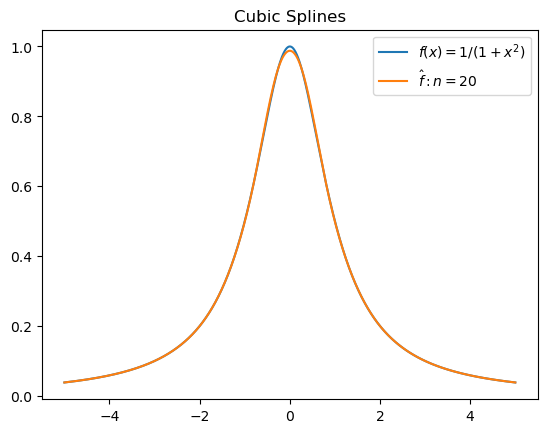

In [19]:
from scipy.interpolate import CubicSpline

f = lambda x: 1 / (1 + x**2)
a, b, n = -5, 5, 20

x = np.linspace(a, b, n)
y = f(x)
f_hat = CubicSpline(x, y)

# Plot the results
plt.title("Cubic Splines")
xg = np.linspace(a, b, 1000)
plt.plot(xg, f(xg), label=r"$f(x) = 1/(1+x^2)$")
plt.plot(xg, f_hat(xg), label=f"$\\hat{{f}}: n = {n}$")
plt.legend()
plt.show()

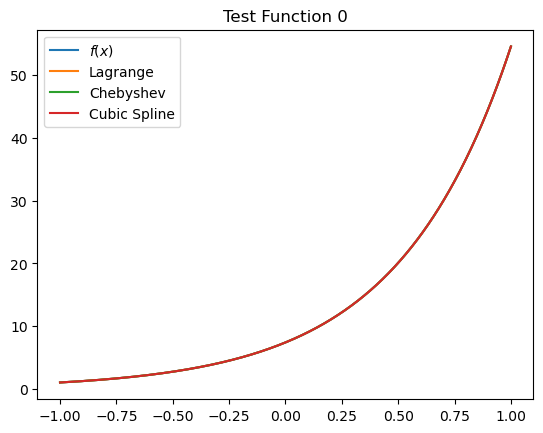

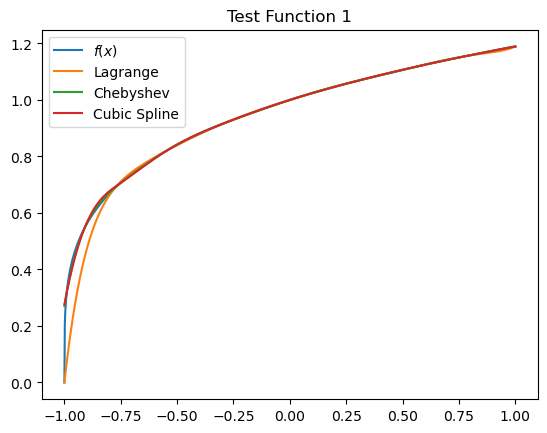

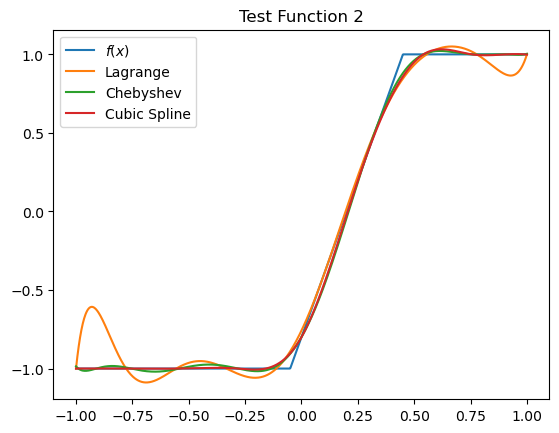

In [20]:
## Test Functions
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline

def f1(x):
    return np.exp(2 * x + 2)

def f2(x):
    return (x + 1) ** (1/4)

def f3(x):
    return np.minimum(np.maximum(-1, 4 * (x - 0.2)), 1)

n = 10

for i, f in enumerate([f1, f2, f3]):
    plt.figure()
    plt.title(f"Test Function {i}")
    xg = np.linspace(-1, 1, 1000)
    plt.plot(xg, f(xg), label=r"$f(x)$")

    x = np.linspace(-1, 1, n)
    y = f(x)

    # Plot with Lagrange
    a = lagrange(x, y)
    plt.plot(xg, a(xg), label="Lagrange")

    # Plot with Chebyshev
    m = n + 1
    a = -1
    b = 1
    z = [-np.cos((2 * k - 1) / (2 * m) * np.pi) for k in range(1, m + 1)]  # interpolation points
    x = (np.array(z) + 1) * (b - a) / 2 + a
    y = f(x)
    c = np.zeros(m + 1)
    for i in range(m + 1):
        numerator = sum(y[k] * T(i, z[k]) for k in range(m))
        denominator = sum(T(i, z[k]) ** 2 for k in range(m))
        c[i] = numerator / denominator

    def approx(x):
        return sum(ci * T(i, 2 * (x - a) / (b - a) - 1) for ci, i in zip(c, range(n + 1)))

    plt.plot(xg, approx(xg), label="Chebyshev")
    
    # Plot with Linear Interpolation
    # Plot with Cubic Splines
    cs = CubicSpline(x, y)
    plt.plot(xg, cs(xg), label="Cubic Spline")

    plt.legend()
    plt.show()

---

## Before the lab

- **Try it:** increase the polynomial order in the approximation examples. When does more flexibility start to hurt (oscillation at the edges)? This is Runge's phenomenon — knowing it exists will save you hours later.
- More worked examples: [additional examples notebook](week07_examples.ipynb).
- Work through [PS6](../psets/PS6.pdf) with your group.

*Next week: economic models — value function iteration.*